In [131]:
#from ydata_profiling import ProfileReport
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
import seaborn as sns


In [132]:

reviews_columns = ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message']
order_items_columns = ["order_id", "order_item_id","product_id","seller_id","price","freight_value"]

orders_df = pd.read_csv('datasets/olist_orders_dataset.csv')
reviews_df = pd.read_csv('datasets/olist_order_reviews_dataset.csv', usecols=reviews_columns)
items_df = pd.read_csv("datasets/olist_order_items_dataset.csv", usecols=order_items_columns)


# fazerEDA(orders_df)
orders_df.shape


(99441, 8)

In [133]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [134]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [135]:
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [136]:
orders_df.isna().sum().sort_values(ascending=False)

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64

# Transformação do dataset REVIEWS

In [137]:
reviews_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [138]:
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   review_id               99224 non-null  str  
 1   order_id                99224 non-null  str  
 2   review_score            99224 non-null  int64
 3   review_comment_title    11568 non-null  str  
 4   review_comment_message  40977 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [139]:
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...


In [140]:
reviews_df.groupby(['review_comment_title']).size().sort_values(ascending=False)


review_comment_title
Recomendo                423
recomendo                345
Bom                      293
super recomendo          270
Excelente                248
                        ... 
 Muito bom                 1
 Entrega parcial           1
 Entrega muito rápida      1
 DUVIDA!                   1
 Bom                       1
Length: 4527, dtype: int64

In [141]:
reviews_df.groupby(['review_score']).size()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
dtype: int64

/tmp/ipykernel_158463/2421149599.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews_df, x='review_score', palette='deep', legend=True)


<Figure size 1200x550 with 0 Axes>

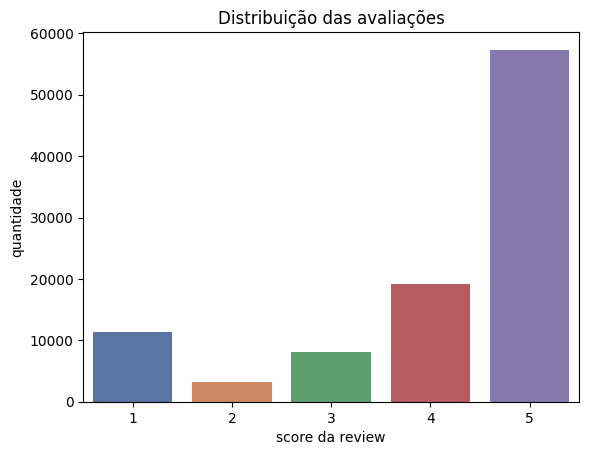

In [142]:
plt.figure(figsize=(12.00, 5.50))
f, axes = plt.subplots(1)
plt.title("Distribuição das avaliações")
plt.xlabel("score da review")
plt.ylabel("quantidade")
sns.countplot(data=reviews_df, x='review_score', palette='deep', legend=True)
plt.show()

In [143]:
print(f'Média de Notas {reviews_df["review_score"].mean()}')
print(f'Médiana de Notas {reviews_df["review_score"].median()}')
print(f'Moda {reviews_df["review_score"].mode()}')


Média de Notas 4.08642062404257
Médiana de Notas 5.0
Moda 0    5
Name: review_score, dtype: int64


In [144]:
reviews_df.isnull().sum()

review_id                     0
order_id                      0
review_score                  0
review_comment_title      87656
review_comment_message    58247
dtype: int64

In [145]:
reviews_df['review_comment_title'] = reviews_df['review_comment_title'].fillna("")
reviews_df['review_comment_message'] = reviews_df['review_comment_message'].fillna("")
reviews_df['avaliacao_completa'] = reviews_df['review_comment_title'] + " " +  reviews_df['review_comment_message'] 
reviews_df['avaliacao_completa'] = reviews_df['avaliacao_completa'].str.strip() 

In [146]:
reviews_df.isnull().sum()

review_id                 0
order_id                  0
review_score              0
review_comment_title      0
review_comment_message    0
avaliacao_completa        0
dtype: int64

In [147]:
def classificar_sentimento(nota):
    if nota <= 3:
        return 'ruim'
    else:
        return 'bom'
    
reviews_df['sentimento'] = reviews_df['review_score'].apply(classificar_sentimento)

In [148]:
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,avaliacao_completa,sentimento
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,,,,bom
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,,,,bom
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,,,,bom
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,,Recebi bem antes do prazo estipulado.,Recebi bem antes do prazo estipulado.,bom
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,,Parabéns lojas lannister adorei comprar pela I...,Parabéns lojas lannister adorei comprar pela I...,bom


In [149]:
reviews_df = reviews_df.drop_duplicates(subset=['review_id'], keep='last')
reviews_df = reviews_df.drop_duplicates(subset=['order_id'], keep='last')

In [150]:
reviews_df['order_id'].duplicated().sum()

np.int64(0)

# Tratamento de Dados de Products

In [160]:
items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


# Processamento de texto em Reviews

In [151]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer


In [152]:
nltk.download('stopwords')
stopwords_pt = stopwords.words('portuguese')

stopwords_pt.extend([
    'produto',
    'comprei',
    'veio',
    'loja',
    'prazo',
    'dia',
    'dias',
    'entregue',
    'entrega',
    'recebi'
])

def obter_top_palavras(textos, top_n=10):
    
    tfidf = TfidfVectorizer(
        stop_words=stopwords_pt,
        max_features=1000, # Pegas X palavras do dataset, nesse caso 1000
        ngram_range=(1, 2) # Pega palavras sozinhas e pares
    )
    
    matriz_tfidf = tfidf.fit_transform(textos)
    
    soma_tfidf = matriz_tfidf.sum(axis=0)
    
    palavras = tfidf.get_feature_names_out()
    df_freq = pd.DataFrame({
        'palavra': palavras, 
        'score': soma_tfidf.A1
    })
    
    return df_freq.sort_values(by='score', ascending=False).head(top_n)

[nltk_data] Downloading package stopwords to /home/chris/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [153]:


# textos_positivos = reviews_df[reviews_df['sentimento'] == 'bom']['avaliacao_completa']
# textos_negativos = reviews_df[reviews_df['sentimento'] == 'ruim']['avaliacao_completa']

# # 4. Ver os resultados!
# print("--- TOP PALAVRAS: REVIEWS POSITIVAS ---")
# print(obter_top_palavras(textos_positivos, 10))

# print("\n--- TOP PALAVRAS: REVIEWS NEGATIVAS ---")
# print(obter_top_palavras(textos_negativos, 10))

# Integração de reviews com OrderListDataset

In [154]:
orders_review_df = orders_df.merge(reviews_df, on="order_id", how="inner")

orders_review_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 98128 entries, 0 to 98127
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       98128 non-null  str  
 1   customer_id                    98128 non-null  str  
 2   order_status                   98128 non-null  str  
 3   order_purchase_timestamp       98128 non-null  str  
 4   order_approved_at              98005 non-null  str  
 5   order_delivered_carrier_date   96423 non-null  str  
 6   order_delivered_customer_date  95335 non-null  str  
 7   order_estimated_delivery_date  98128 non-null  str  
 8   review_id                      98128 non-null  str  
 9   review_score                   98128 non-null  int64
 10  review_comment_title           98128 non-null  str  
 11  review_comment_message         98128 non-null  str  
 12  avaliacao_completa             98128 non-null  str  
 13  sentimento                 

In [155]:
orders_review_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,avaliacao_completa,sentimento
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4,,"Não testei o produto ainda, mas ele veio corre...","Não testei o produto ainda, mas ele veio corre...",bom
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,Muito boa a loja Muito bom o produto.,bom
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5,,,,bom
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,359d03e676b3c069f62cadba8dd3f6e8,5,,O produto foi exatamente o que eu esperava e e...,O produto foi exatamente o que eu esperava e e...,bom
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,e50934924e227544ba8246aeb3770dd4,5,,,,bom


# Treinamento do Modelo

In [156]:
seed = 42

colunas_para_dropar = [
    'order_id', 'customer_id', 'review_id', # IDs não ensinam nada
    'review_score',                         # Vazamento de dados!
    'review_comment_title',                 # Já está dentro da avaliacao_completa
    'review_comment_message',               # Já está dentro da avaliacao_completa
    'order_status',                         # A maioria deve ser 'delivered', não ajuda muito
    'order_purchase_timestamp',             # (Vamos ignorar as datas por enquanto para simplificar)
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

X = orders_review_df.drop(columns=['sentimento'] + colunas_para_dropar)
y = orders_review_df['sentimento']

X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

randomForestModel = RandomForestClassifier(n_estimators=100, random_state=seed)
gradientBostModel = GradientBoostingClassifier(random_state=seed)
LogisticRegressionModel = LogisticRegression(random_state=seed)

# randomForestModel.fit(X_train, y_train)
# gradientBostModel.fit(X_train, y_train)
# LogisticRegressionModel.fit(X_train, y_train)

# randomForestModel.predict(y_test)
# gradientBostModel.predict(y_test)
# LogisticRegressionModel.predict(y_test)

X


,avaliacao_completa
0,"Não testei o produto ainda, mas ele veio corre..."
1,Muito boa a loja Muito bom o produto.
2,
3,O produto foi exatamente o que eu esperava e e...
4,
...,...
98123,
98124,So uma peça que veio rachado mas tudo bem rs
98125,Foi entregue antes do prazo.
98126,Foi entregue somente 1. Quero saber do outro p...


In [ ]:




    reviews_columns = ['review_id', 'order_id', 'review_score']
    order_items_columns = ["order_id", "order_item_id","product_id","seller_id","price","freight_value"]

    orders_df = pd.read_csv('datasets/olist_orders_dataset.csv')









    reviews_df = pd.read_csv('datasets/olist_order_reviews_dataset.csv', usecols=reviews_columns)
    items = pd.read_csv("datasets/olist_order_items_dataset.csv", usecols=order_items_columns)

    orders_review_df = orders_df.merge(reviews_df, on="order_id", how="inner")

    orders_review_df['order_delivered_customer_date'] = pd.to_datetime(orders_review_df['order_delivered_customer_date'])
    orders_review_df['order_estimated_delivery_date'] = pd.to_datetime(orders_review_df['order_estimated_delivery_date'])

    orders_review_df['dias_atraso'] = (orders_review_df['order_delivered_customer_date'] - 
                                    orders_review_df['order_estimated_delivery_date']).dt.days

    orders_review_df['review_e_negativa'] = np.where(orders_review_df['review_score'] < 4, 1, 0)

    df_model = orders_review_df[['order_id', 'dias_atraso', 'review_e_negativa']].dropna()

    itens_resumo = items.groupby("order_id").agg({
        'price': 'sum',
        'freight_value': 'sum',
        'order_item_id': 'count'
    }).reset_index()

#     df_exploracao = df_model.merge(itens_resumo, on='order_id', how='inner')

#     df_exploracao.rename(columns={
#         "price": 'preço',
#         "freight_value": "frete"
#     }, inplace=True)

#     colunas_corr = ['review_e_negativa', 'dias_atraso', 'preço', 'frete']
#     matriz_corr = df_exploracao[colunas_corr].corr()

#     X = df_exploracao[['dias_atraso', 'preço', 'frete']]
#     y = df_model['review_e_negativa']

#     scaller = StandardScaler()
#     X_scaled = scaller.fit_transform(X)


#     x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#     model = LogisticRegression(penalty="l2")
#     model.fit(x_train, y_train)

#     # 6. Previsão e Gráfico
#     y_pred = model.predict(x_test)
#     acuracia = accuracy_score(y_test, y_pred)

#     print(f"Acurácia: {acuracia:.2%}")

#     # Plotando a Matriz de Confusão
#     cm = confusion_matrix(y_test, y_pred)
#     disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Boa (0)', 'Ruim (1)'])

#     plt.figure(figsize=(8, 6))
#     sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
#     plt.title('Correlação: Nota Baixa vs Logística e Preço')
#     plt.show()


#     fig, ax = plt.subplots(figsize=(8, 6))
#     disp.plot(cmap='RdPu', ax=ax) # RdPu dá um tom profissional/industrial
#     ax.set_title(f'Matriz de Confusão \nAcurácia Total: {acuracia:.2%}')
#     plt.show()

#     # df_vendas = pd.merge(items, products, on='product_id', how='left')
#     # df_vendas = pd.merge(df_vendas, orders_df, on='order_id', how='left')

#     # df_tv = df_vendas[df_vendas['product_category_name'].str.contains('eletronicos|informatica|telefonia', na=False)]

#     # profile = ProfileReport(reviews_df, title="Auditoria de Reviews Olist", explorative=True)
#     # profile.to_file("auditoria_reviews.html")

#     model_refinado = LogisticRegression(penalty="l2", class_weight="balanced", C=0.1, max_iter=1000)
#     model_refinado.fit(x_train, y_train)
#     y_pred_refinado = model_refinado.predict(x_test)

#     # --- 2. Plotagem Comparativa ---

#     fig, ax = plt.subplots(1, 2, figsize=(15, 6))

#     # Matriz do Modelo Simples
#     cm_simples = confusion_matrix(y_test, y_pred)
#     disp_s = ConfusionMatrixDisplay(confusion_matrix=cm_simples, display_labels=['Boa (0)', 'Ruim (1)'])
#     disp_s.plot(values_format='d', cmap='Blues', ax=ax[0])
#     ax[0].set_title(f'Modelo Simples\nAcurácia: {accuracy_score(y_test, y_pred):.2%}')

#     # Matriz do Modelo Refinado
#     cm_refinado = confusion_matrix(y_test, y_pred_refinado)
#     disp_r = ConfusionMatrixDisplay(confusion_matrix=cm_refinado, display_labels=['Boa (0)', 'Ruim (1)'])
#     disp_r.plot(values_format='d', cmap='RdPu', ax=ax[1])
#     ax[1].set_title(f'Modelo Refinado (Balanced + C=0.1)\nAcurácia: {accuracy_score(y_test, y_pred_refinado):.2%}')

#     plt.tight_layout()
#     plt.show()

#     # --- 3. Exibição dos Relatórios Técnicos (Prints) ---

#     print("\n" + "="*30)
#     print("RELATÓRIO: MODELO SIMPLES")
#     print("="*30)
#     print(classification_report(y_test, y_pred, target_names=['Boa (0)', 'Ruim (1)']))

#     print("\n" + "="*30)
#     print("RELATÓRIO: MODELO REFINADO")
#     print("="*30)
#     print(classification_report(y_test, y_pred_refinado, target_names=['Boa (0)', 'Ruim (1)']))
    
# main()